## Tasks and Inputs

Import your wild boar dataset `wildschwein_BE_2056.csv` (on moodle) as an `sf` object

In [1]:
library("tidyverse")
library("sf")


wildschwein <- read_delim("Data/wildschwein_BE_2056.csv", ",") %>%
    st_as_sf(coords = c("E", "N"), crs = 2056, remove = FALSE)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE

Rows: 51246 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): TierID, TierName
dbl  (3): CollarID, E, N
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column

In [2]:
head(wildschwein)
st_crs(wildschwein)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



TierID,TierName,CollarID,DatetimeUTC,E,N,geometry
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>
002A,Sabi,12275,2014-08-22 21:00:12,2570409,1204752,POINT (2570409 1204752)
002A,Sabi,12275,2014-08-22 21:15:16,2570402,1204863,POINT (2570402 1204863)
002A,Sabi,12275,2014-08-22 21:30:43,2570394,1204826,POINT (2570394 1204826)
002A,Sabi,12275,2014-08-22 21:46:07,2570379,1204817,POINT (2570379 1204817)
002A,Sabi,12275,2014-08-22 22:00:22,2570390,1204818,POINT (2570390 1204818)
002A,Sabi,12275,2014-08-22 22:15:10,2570390,1204825,POINT (2570390 1204825)


Coordinate Reference System:
  User input: EPSG:2056 
  wkt:
PROJCRS["CH1903+ / LV95",
    BASEGEOGCRS["CH1903+",
        DATUM["CH1903+",
            ELLIPSOID["Bessel 1841",6377397.155,299.1528128,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4150]],
    CONVERSION["Swiss Oblique Mercator 1995",
        METHOD["Hotine Oblique Mercator (variant B)",
            ID["EPSG",9815]],
        PARAMETER["Latitude of projection centre",46.9524055555556,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8811]],
        PARAMETER["Longitude of projection centre",7.43958333333333,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8812]],
        PARAMETER["Azimuth at projection centre",90,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8813]],
        PARAMETER["Angle from Rectified to Skew Grid",90,
            ANGLEUNIT["deg

Download the dataset `Feldaufnahmen_Fanel.gpkg` (on moodle) and save it to your project folder. This is a vector dataset stored in the filetype Geopackage, which is similar to a Shapefile, with some advantages (see the website [shapefile must die](http://switchfromshapefile.org/)).

Also download the dataset `vegetationshoehe_LFI.tif` (on moodle) and store it in your project folder. This is a raster dataset stored in a Geotiff.

### Tasks 1: Import and visualize spatial data
Since `Feldaufnahmen_Fanel.gpkg` is a **vector dataset**, you can import it using `read_sf()`. Explore this dataset in R to answer the following questions:

- What information does the dataset contain?
- What is the geometry type of the dataset (possible types are: Point, Lines and Polygons)?
- What are the data types of the other columns?
- What is the coordinate system of the dataset?

In [3]:
feldaufnahmen <- read_sf("Data/Feldaufnahmen_Fanel.gpkg")
head(feldaufnahmen)
st_crs(feldaufnahmen)

FieldID,Frucht,geom
<dbl>,<chr>,<POLYGON [m]>
1,Roggen,"POLYGON ((2570914 1202743, ..."
0,NA,"POLYGON ((2570893 1202758, ..."
0,NA,"POLYGON ((2570868 1202776, ..."
2,Wiese,"POLYGON ((2570882 1203234, ..."
3,Weide,"POLYGON ((2570249 1203116, ..."
5,Weide,"POLYGON ((2570378 1203320, ..."


Coordinate Reference System:
  User input: CH1903+ / LV95 
  wkt:
PROJCRS["CH1903+ / LV95",
    BASEGEOGCRS["CH1903+",
        DATUM["CH1903+",
            ELLIPSOID["Bessel 1841",6377397.155,299.1528128,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4150]],
    CONVERSION["Swiss Oblique Mercator 1995",
        METHOD["Hotine Oblique Mercator (variant B)",
            ID["EPSG",9815]],
        PARAMETER["Latitude of projection centre",46.9524055555556,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8811]],
        PARAMETER["Longitude of projection centre",7.43958333333333,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8812]],
        PARAMETER["Azimuth at projection centre",90,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8813]],
        PARAMETER["Angle from Rectified to Skew Grid",90,
            ANGLEUNIT

#### Answers
**What information does the dataset contain?**

- FieldID --> Feldplot
- Frucht --> Welche Frucht wird auf diesem Feld angebaut
- geom --> Geometrie

**What is the geometry type of the dataset (possible types are: Point, Lines and Polygons)?** --> Polygon

**What are the data types of the other columns?**

- FieldID = dbl
- Frucht = Character

**What is the coordinate system of the dataset?** --> CH1903+ / LV95

### Task 2: Annotate Trajectories from vector data
We would like to know **what crop was visited by which wild boar, and at what time**. Since the crop data is most relevant in summer, filter your wild boar data to the months may to june first and save the output to a new variable. Overlay the filtered dataset with your `fanel` data to verify the spatial overlap.

To sematically annotate each wild boar location with crop information, you can use a spatial join with the function `st_join()`. Do this and explore your annotated dataset.

In [4]:
head(wildschwein)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>
002A,Sabi,12275,2014-08-22 21:00:12,2570409,1204752,POINT (2570409 1204752)
002A,Sabi,12275,2014-08-22 21:15:16,2570402,1204863,POINT (2570402 1204863)
002A,Sabi,12275,2014-08-22 21:30:43,2570394,1204826,POINT (2570394 1204826)
002A,Sabi,12275,2014-08-22 21:46:07,2570379,1204817,POINT (2570379 1204817)
002A,Sabi,12275,2014-08-22 22:00:22,2570390,1204818,POINT (2570390 1204818)
002A,Sabi,12275,2014-08-22 22:15:10,2570390,1204825,POINT (2570390 1204825)


In [5]:
wildschwein_summer <- wildschwein %>%
  filter(month(DatetimeUTC) == 5 | month(DatetimeUTC) == 6)

In [6]:
head(wildschwein_summer)
min(wildschwein_summer$DatetimeUTC)
max(wildschwein_summer$DatetimeUTC)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>
002A,Sabi,12275,2015-05-01 00:00:17,2570093,1205256,POINT (2570093 1205256)
002A,Sabi,12275,2015-05-01 00:15:25,2570093,1205249,POINT (2570093 1205249)
002A,Sabi,12275,2015-05-01 00:30:15,2570091,1205253,POINT (2570091 1205253)
002A,Sabi,12275,2015-05-01 00:45:15,2570059,1205242,POINT (2570059 1205242)
002A,Sabi,12275,2015-05-01 01:00:30,2570078,1205246,POINT (2570078 1205246)
002A,Sabi,12275,2015-05-01 01:15:43,2570096,1205256,POINT (2570096 1205256)


[1] "2015-05-01 00:00:07 UTC"

[1] "2015-06-30 23:45:16 UTC"

#### Plot einzeln

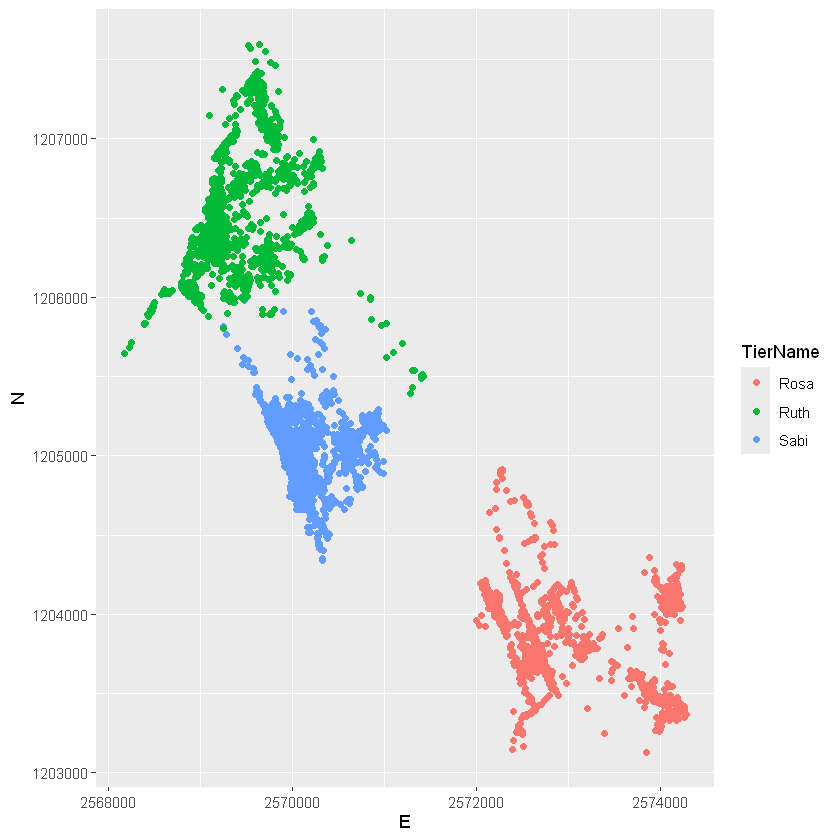

In [7]:
ggplot(wildschwein_summer, aes(E, N, colour = TierName)) +
    geom_point()

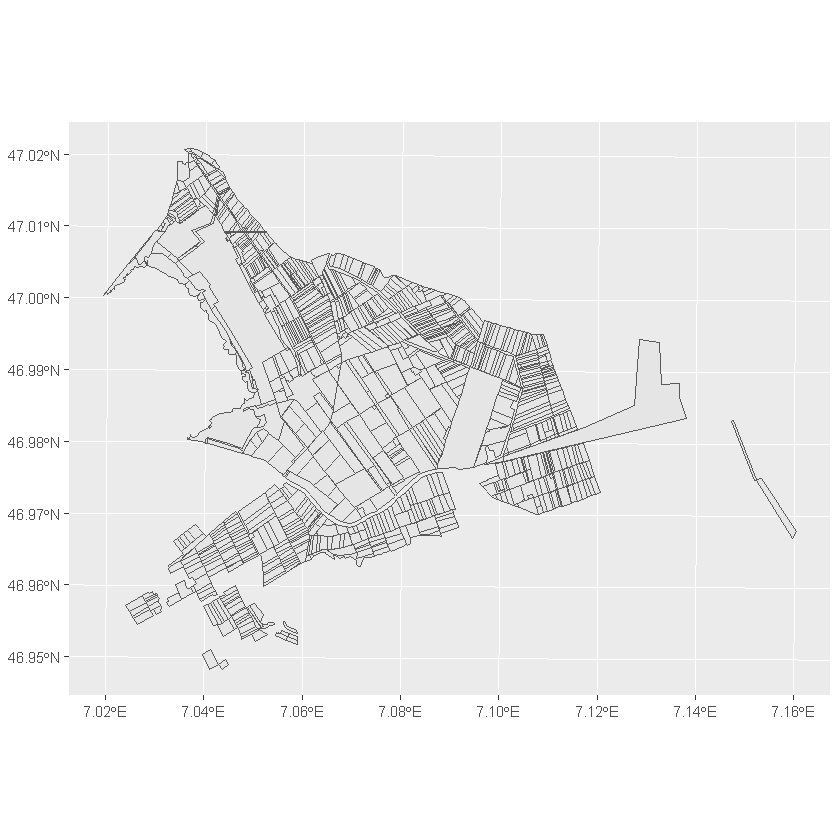

In [8]:
ggplot(feldaufnahmen) +
    geom_sf()

#### Plot Overlay Polygone und Punkte

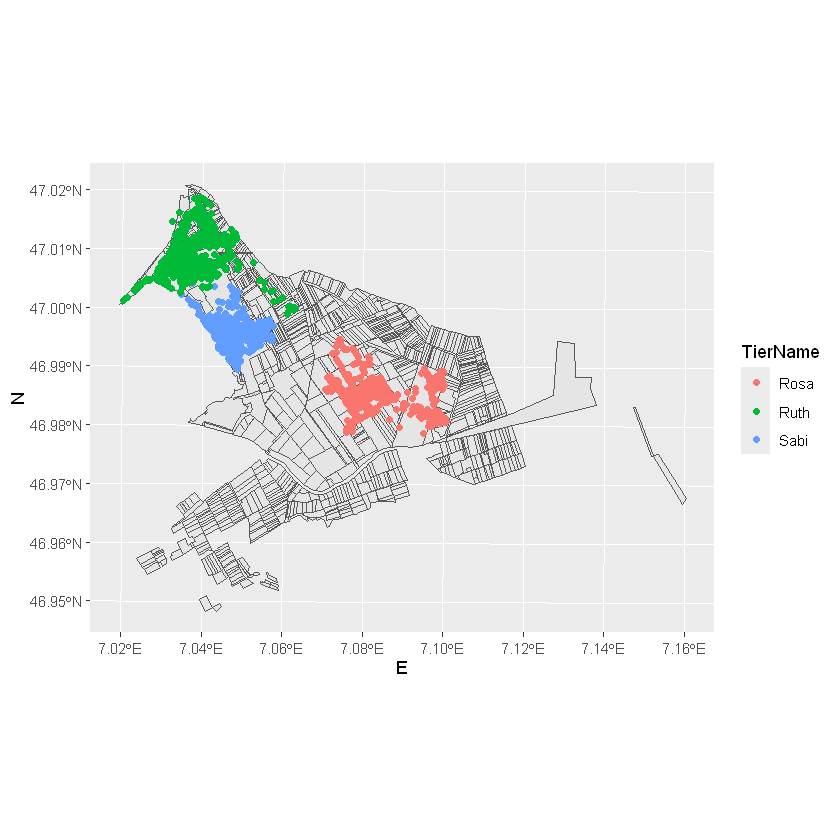

In [9]:
ggplot() +
  geom_sf(data = feldaufnahmen) +
  geom_point(
    data = wildschwein_summer,
    aes(x = E, y = N, colour = TierName)
  )



── tmap v3 code detected ───────────────────────────────────────────────────────────────────────────────────────────────

[v3->v4] `tm_polygons()`: use 'fill' for the fill color of polygons/symbols (instead of 'col'), and 'col' for the
outlines (instead of 'border.col').
This message is displayed once every 8 hours.
[v3->v4] `tm_dots()`: use `fill_alpha` instead of `alpha`.
[tm_dots()] Arguments `x` and `y` unknown.


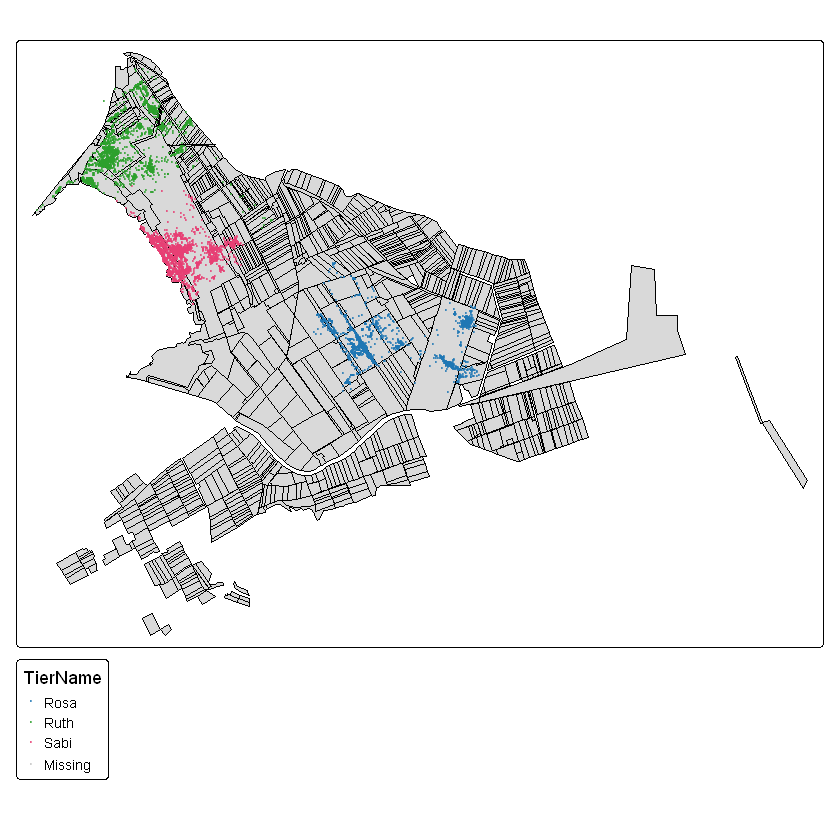

In [10]:
library(tmap)

tm_shape(feldaufnahmen) +
  tm_polygons(
    col = NA,
    border.col = "black"
  ) +
  tm_shape(wildschwein_summer) +
  tm_dots(
    x = "E",
    y = "N",
    col = "TierName",
    size = 0.05,
    alpha = 0.6
  )

#### Spatial Join

In [11]:
head(wildschwein_summer)
head(feldaufnahmen)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>
002A,Sabi,12275,2015-05-01 00:00:17,2570093,1205256,POINT (2570093 1205256)
002A,Sabi,12275,2015-05-01 00:15:25,2570093,1205249,POINT (2570093 1205249)
002A,Sabi,12275,2015-05-01 00:30:15,2570091,1205253,POINT (2570091 1205253)
002A,Sabi,12275,2015-05-01 00:45:15,2570059,1205242,POINT (2570059 1205242)
002A,Sabi,12275,2015-05-01 01:00:30,2570078,1205246,POINT (2570078 1205246)
002A,Sabi,12275,2015-05-01 01:15:43,2570096,1205256,POINT (2570096 1205256)


FieldID,Frucht,geom
<dbl>,<chr>,<POLYGON [m]>
1,Roggen,"POLYGON ((2570914 1202743, ..."
0,NA,"POLYGON ((2570893 1202758, ..."
0,NA,"POLYGON ((2570868 1202776, ..."
2,Wiese,"POLYGON ((2570882 1203234, ..."
3,Weide,"POLYGON ((2570249 1203116, ..."
5,Weide,"POLYGON ((2570378 1203320, ..."


In [12]:
wildschwein_summer_join <- st_join(wildschwein_summer, feldaufnahmen)
head(wildschwein_summer_join)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,FieldID,Frucht
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<chr>
002A,Sabi,12275,2015-05-01 00:00:17,2570093,1205256,POINT (2570093 1205256),0,Wald
002A,Sabi,12275,2015-05-01 00:15:25,2570093,1205249,POINT (2570093 1205249),0,Wald
002A,Sabi,12275,2015-05-01 00:30:15,2570091,1205253,POINT (2570091 1205253),0,Wald
002A,Sabi,12275,2015-05-01 00:45:15,2570059,1205242,POINT (2570059 1205242),0,Wald
002A,Sabi,12275,2015-05-01 01:00:30,2570078,1205246,POINT (2570078 1205246),0,Wald
002A,Sabi,12275,2015-05-01 01:15:43,2570096,1205256,POINT (2570096 1205256),0,Wald




── tmap v3 code detected ───────────────────────────────────────────────────────────────────────────────────────────────

[v3->v4] `tm_polygons()`: use `fill_alpha` instead of `alpha`.
[v3->v4] `tm_dots()`: use `fill_alpha` instead of `alpha`.
[tm_dots()] Arguments `x` and `y` unknown.
Warning message:
"Number of levels of the variable assigned to the aesthetic "fill" of the layer "polygons" is 44, which is larger than n.max (which is 30), so levels are combined."
[plot mode] fit legend/component: Some legend items or map compoments do not fit well, and are therefore rescaled.
ℹ Set the tmap option `component.autoscale = FALSE` to disable rescaling.


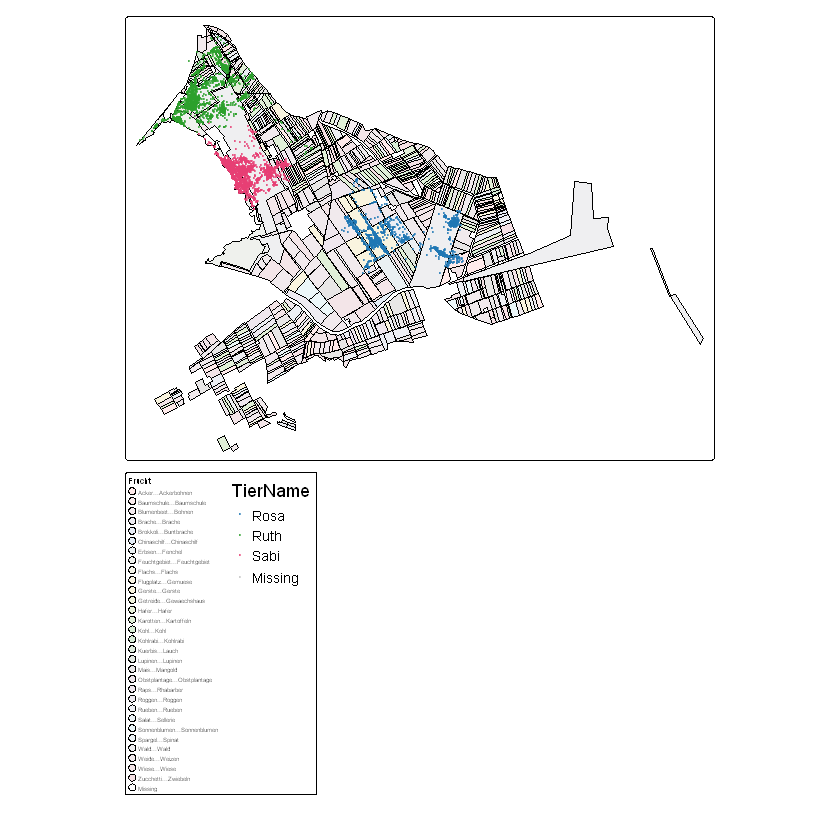

In [13]:
tm_shape(feldaufnahmen) +
  tm_polygons(
    col = "Frucht",
    border.col = "black", 
    alpha = 0.2
  ) +
  tm_shape(wildschwein_summer_join) +
  tm_dots(
    x = "E",
    y = "N",
    col = "TierName",
    size = 0.05,
    alpha = 0.6
  )

In [14]:
tmap_mode("view")

m <- tm_shape(feldaufnahmen) +
  tm_polygons(
    col = "Frucht",
    border.col = "black", 
    alpha = 0.2
  ) +
  tm_shape(wildschwein_summer_join) +
  tm_dots(
    x = "E",
    y = "N",
    col = "TierName",
    size = 0.05,
    alpha = 0.6
  )

ℹ tmap modes "plot" - "view"
ℹ toggle with `tmap::ttm()`
This message is displayed once per session.


── tmap v3 code detected ───────────────────────────────────────────────────────────────────────────────────────────────

[v3->v4] `tm_polygons()`: use `fill_alpha` instead of `alpha`.
[v3->v4] `tm_dots()`: use `fill_alpha` instead of `alpha`.
[tm_dots()] Arguments `x` and `y` unknown.


In [15]:
print(tmap_leaflet(m))
tmap_save(m, "Week_7_Karte.html")

Warning message:
"Number of levels of the variable assigned to the aesthetic "fill" of the layer "polygons" is 44, which is larger than n.max (which is 30), so levels are combined."
Registered S3 method overwritten by 'jsonify':
  method     from    
  print.json jsonlite

Warning message:
"Number of levels of the variable assigned to the aesthetic "fill" of the layer "polygons" is 44, which is larger than n.max (which is 30), so levels are combined."
Interactive map saved to C:\Users\vikto\1 MeinJupyter\1 Master\Patterns & Trends\Week_7_Karte.html



### Task 3: Explore annotated trajectories
Think of ways you could visually explore the spatio-temporal patterns of wild boar in relation to the crops. In our example below we visualize the percentage of samples in a given crop per hour.

#### Welche Klassen kommen am häufigsten vor?

In [16]:
wildschwein_summer_join %>%
  count(Frucht, sort = TRUE) %>%
  slice_head(n = 6)

Frucht,n,geometry
<chr>,<int>,<MULTIPOINT [m]>
Wald,9459,MULTIPOINT ((2568949 120642...
Feuchtgebiet,2201,MULTIPOINT ((2568174 120564...
Gerste,1479,MULTIPOINT ((2572140 120464...
NA,608,MULTIPOINT ((2569055 120656...
Rueben,445,MULTIPOINT ((2569633 120710...
Bohnen,329,MULTIPOINT ((2569388 120727...


Für die Visualisierung verwende ich `Wald`, `Feuchtgebiet`, `Gerste`, `Rueben` und eine Klasse für alle anderen `other`.

In [17]:
wildschwein_summer_join <- wildschwein_summer_join %>%
    mutate(Frucht_reclass = case_when(
      Frucht %in% c("Wald", "Feuchtgebiet", "Gerste", "Rueben") ~ Frucht,
      TRUE ~ "other"))

In [18]:
unique(wildschwein_summer_join$Frucht_reclass)

[1] "Wald"         "other"        "Feuchtgebiet" "Rueben"       "Gerste"

In [19]:
#head(wildschwein_summer_join)

In [20]:
df <- wildschwein_summer_join %>% 
    mutate(hour = hour(DatetimeUTC))

In [21]:
head(df)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,FieldID,Frucht,Frucht_reclass,hour
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<chr>,<chr>,<int>
002A,Sabi,12275,2015-05-01 00:00:17,2570093,1205256,POINT (2570093 1205256),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 00:15:25,2570093,1205249,POINT (2570093 1205249),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 00:30:15,2570091,1205253,POINT (2570091 1205253),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 00:45:15,2570059,1205242,POINT (2570059 1205242),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 01:00:30,2570078,1205246,POINT (2570078 1205246),0,Wald,Wald,1
002A,Sabi,12275,2015-05-01 01:15:43,2570096,1205256,POINT (2570096 1205256),0,Wald,Wald,1


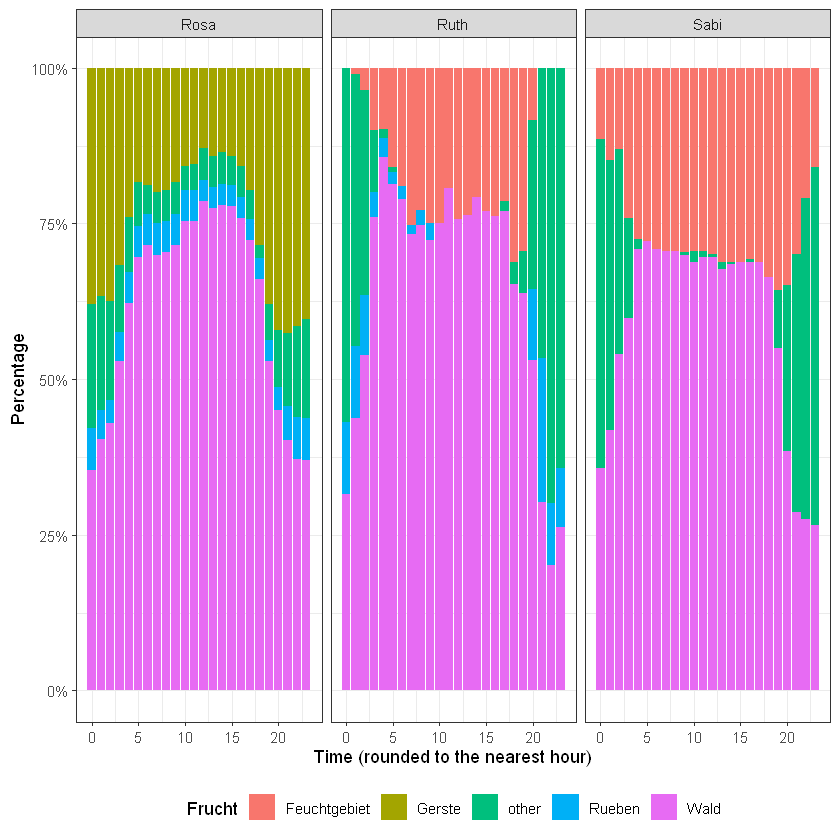

In [22]:
ggplot(df, aes(x = hour, fill = Frucht_reclass)) +
    geom_bar(position = "fill") +
    facet_wrap(~TierName) +
    scale_y_continuous(labels = scales::percent) +
    labs(x = "Time (rounded to the nearest hour)", y = "Percentage", fill = "Frucht") +
    theme_bw() +
    theme(legend.position = "bottom")

### Task 4: Import and visualize vegetationindex (raster data)
In terms of raster data, we have prepared the [Vegetation Height Model](https://map.geo.admin.ch/index.html#/map?lang=en&center=2570723.63,1205388.11&z=7&topic=ech&layers=ch.bafu.landesforstinventar-vegetationshoehenmodell@year=current&bgLayer=ch.swisstopo.pixelkarte-grau) provided by the Swiss National Forest Inventory (NFI). This dataset contains high resolution information (1x1 Meter) on the **vegetation height**, which is determined from the difference between the digital surface models DSM and the digital terrain model by swisstopo (swissAlti3D). Buildings are eliminated using a combination of the ground areas of the swisstopo topographic landscape model (TLM) and spectral information from the stereo aerial photos.

**Import this dataset** using the function `rast` from the package `terra`. Visualize the raster data using the base plot function and `tmap`. We do not recommend using ggplot2 in this case, as is very slow with raster data.

In [23]:
library("terra")

terra 1.8.70


Attache Paket: 'terra'


Das folgende Objekt ist maskiert 'package:tidyr':

    extract




In [24]:
raster <- rast("Data/vegetationshoehe_LFI.tif")
raster

class       : SpatRaster 
size        : 5303, 7001, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 2568153, 2575154, 1202306, 1207609  (xmin, xmax, ymin, ymax)
coord. ref. : +proj=somerc +lat_0=46.9524055555556 +lon_0=7.43958333333333 +k_0=1 +x_0=2600000 +y_0=1200000 +ellps=bessel +units=m +no_defs 
source      : vegetationshoehe_LFI.tif 
name        : vegetationshoehe_LFI 
min value   :                 0.00 
max value   :                47.58 

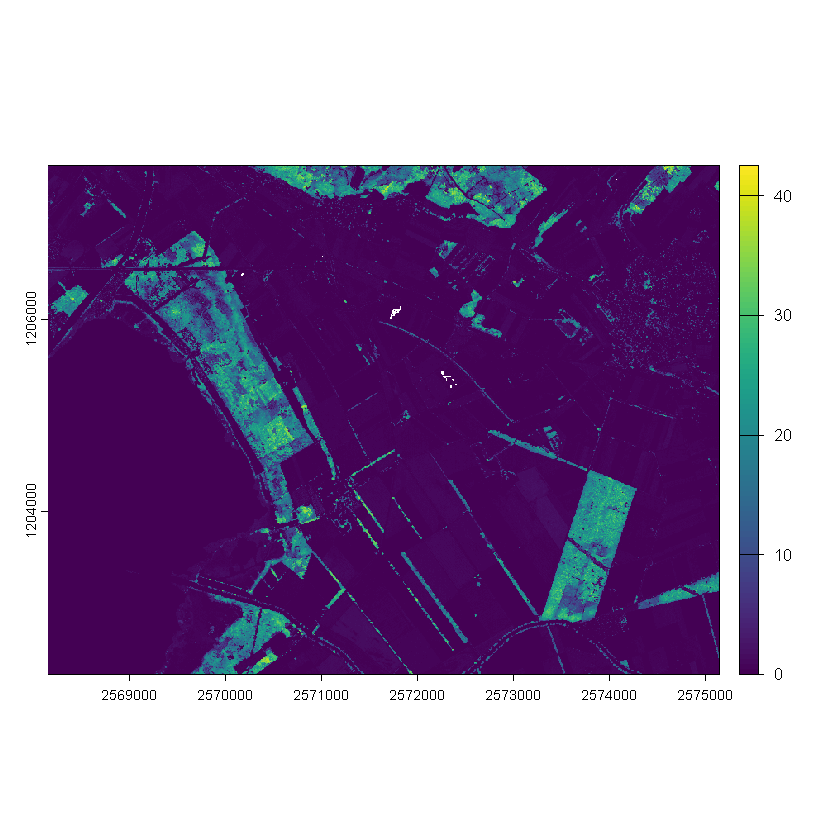

In [25]:
plot(raster)

ℹ tmap modes "plot" - "view"


── tmap v3 code detected ───────────────────────────────────────────────────────────────────────────────────────────────

[v3->v4] `tm_raster()`: migrate the argument(s) related to the legend of the visual variable `col` namely 'title' to
'col.legend = tm_legend(<HERE>)'
SpatRaster object downsampled to 2753 by 3634 cells.



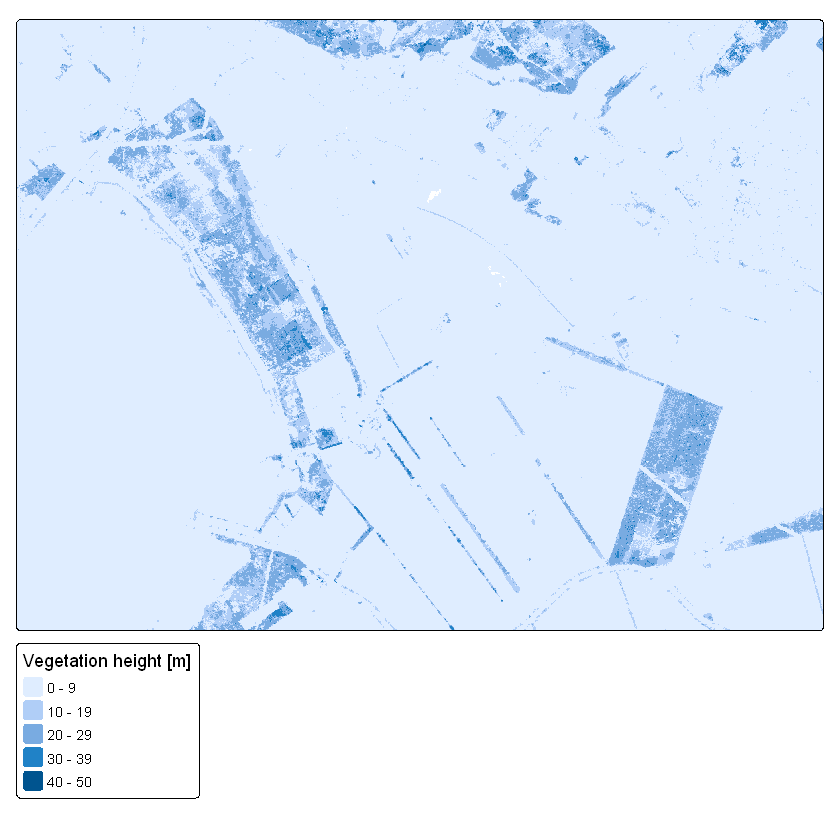

In [26]:
tmap_mode("plot")
tm_shape(raster) +
  tm_raster(
    title = "Vegetation height [m]"
  ) 

### Task 5: Annotate Trajectories from raster data
Semantically annotate your wild boar locations with the vegetation index (similar as you did with the crop data in Task 2). Since you are annotating a vector dataset with information from a raster dataset, **you cannot use `st_join` but need the function `extract` from the `terra` package**. Read the help on the extract function to see what the function expects [here](https://tmieno2.github.io/R-as-GIS-for-Economists/extracting-values-from-raster-layers-for-vector-data.html). 

You can now explore the spatio-temporal patterns of this new data, similarly to as we did in Task 3.

In [27]:
head(df)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,FieldID,Frucht,Frucht_reclass,hour
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<chr>,<chr>,<int>
002A,Sabi,12275,2015-05-01 00:00:17,2570093,1205256,POINT (2570093 1205256),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 00:15:25,2570093,1205249,POINT (2570093 1205249),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 00:30:15,2570091,1205253,POINT (2570091 1205253),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 00:45:15,2570059,1205242,POINT (2570059 1205242),0,Wald,Wald,0
002A,Sabi,12275,2015-05-01 01:00:30,2570078,1205246,POINT (2570078 1205246),0,Wald,Wald,1
002A,Sabi,12275,2015-05-01 01:15:43,2570096,1205256,POINT (2570096 1205256),0,Wald,Wald,1


In [28]:
veg_height_points <- terra::extract(raster, vect(df))

#--- take a look ---#
head(veg_height_points)

,ID,vegetationshoehe_LFI
,<dbl>,<dbl>
1,1,8.74
2,2,20.62
3,3,11.06
4,4,26.15
5,5,17.48
6,6,13.17


In [29]:
nrow(df) == nrow(veg_height_points)

[1] TRUE

In [30]:
df_veg_height <- df %>%
  mutate(
    vegetationshoehe_LFI = veg_height_points$vegetationshoehe_LFI)

In [31]:
head(df_veg_height)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,FieldID,Frucht,Frucht_reclass,hour,vegetationshoehe_LFI
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<chr>,<chr>,<int>,<dbl>
002A,Sabi,12275,2015-05-01 00:00:17,2570093,1205256,POINT (2570093 1205256),0,Wald,Wald,0,8.74
002A,Sabi,12275,2015-05-01 00:15:25,2570093,1205249,POINT (2570093 1205249),0,Wald,Wald,0,20.62
002A,Sabi,12275,2015-05-01 00:30:15,2570091,1205253,POINT (2570091 1205253),0,Wald,Wald,0,11.06
002A,Sabi,12275,2015-05-01 00:45:15,2570059,1205242,POINT (2570059 1205242),0,Wald,Wald,0,26.15
002A,Sabi,12275,2015-05-01 01:00:30,2570078,1205246,POINT (2570078 1205246),0,Wald,Wald,1,17.48
002A,Sabi,12275,2015-05-01 01:15:43,2570096,1205256,POINT (2570096 1205256),0,Wald,Wald,1,13.17


#### Vegetationshöhe gruppieren

In [32]:
summary(df_veg_height$vegetationshoehe_LFI)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   0.780   4.560   9.362  18.690  36.380       2 

In [33]:
df_veg_height <- df_veg_height %>%
    mutate(
    veg_height_class = case_when(
      vegetationshoehe_LFI < 1 ~ "0–1 m",
      vegetationshoehe_LFI < 5 ~ "1–5 m",
      vegetationshoehe_LFI < 10 ~ "5–10 m",
      vegetationshoehe_LFI < 20 ~ "10–20 m",
      vegetationshoehe_LFI >= 20 ~ ">20 m" ))

In [34]:
df_veg_height <- df_veg_height %>%
  mutate(
    veg_height_class = factor(
      veg_height_class,
      levels = c("0–1 m", "1–5 m", "5–10 m", "10–20 m", ">20 m")
    )
  )

In [35]:
head(df_veg_height)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,FieldID,Frucht,Frucht_reclass,hour,vegetationshoehe_LFI,veg_height_class
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<chr>,<chr>,<int>,<dbl>,<fct>
002A,Sabi,12275,2015-05-01 00:00:17,2570093,1205256,POINT (2570093 1205256),0,Wald,Wald,0,8.74,5–10 m
002A,Sabi,12275,2015-05-01 00:15:25,2570093,1205249,POINT (2570093 1205249),0,Wald,Wald,0,20.62,>20 m
002A,Sabi,12275,2015-05-01 00:30:15,2570091,1205253,POINT (2570091 1205253),0,Wald,Wald,0,11.06,10–20 m
002A,Sabi,12275,2015-05-01 00:45:15,2570059,1205242,POINT (2570059 1205242),0,Wald,Wald,0,26.15,>20 m
002A,Sabi,12275,2015-05-01 01:00:30,2570078,1205246,POINT (2570078 1205246),0,Wald,Wald,1,17.48,10–20 m
002A,Sabi,12275,2015-05-01 01:15:43,2570096,1205256,POINT (2570096 1205256),0,Wald,Wald,1,13.17,10–20 m


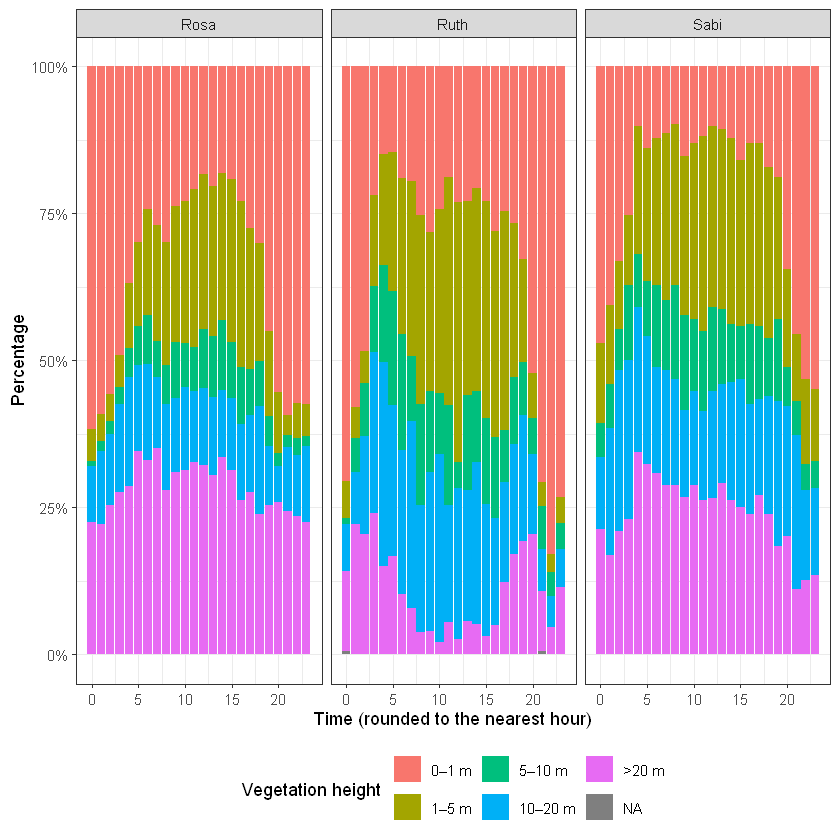

In [36]:
ggplot(df_veg_height, aes(x = hour, fill = veg_height_class)) +
    geom_bar(position = "fill") +
    facet_wrap(~TierName) +
    scale_y_continuous(labels = scales::percent) +
    labs(x = "Time (rounded to the nearest hour)", y = "Percentage", fill = "Vegetation height") +
    theme_bw() +
    theme(legend.position = "bottom")